# Meteorological Risk Factors for Plasmopara viticola Infection in European Vineyards
## A Data Science Analysis of Disease Occurrence and Meteorological Conditions

**SoftUni Data Science Program — Final Exam Project**  
**Author:** Pavel Ivanov  


## 1. Setup - Imports & Data Loading

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

# Bordeaux dataset
bordeaux = pd.read_excel('../data/raw/plosone_bordeaux_downy_mildew_s1.xlsx')

print(f"Shape: {bordeaux.shape}")
print(f"\nColumns:\n{list(bordeaux.columns)}")
bordeaux.head()

Shape: (156, 15)

Columns:
['Id_Parc', 'Date_App', 'Year', 'Mar_p_total_moy', 'Apr_p_total_moy', 'May_p_total_moy', 'Jun_p_total_moy', 'Mar_tmean_h_q_moy', 'Apr_tmean_h_q_moy', 'May_tmean_h_q_moy', 'Jun_tmean_h_q_moy', 'MFF_fin', 'MFI_fin', 'MGF_fin', 'MGI_fin']


C:\Users\User\miniconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Id_Parc,Date_App,Year,Mar_p_total_moy,Apr_p_total_moy,May_p_total_moy,Jun_p_total_moy,Mar_tmean_h_q_moy,Apr_tmean_h_q_moy,May_tmean_h_q_moy,Jun_tmean_h_q_moy,MFF_fin,MFI_fin,MGF_fin,MGI_fin
0,1,22.0,2,0.764516,0.343333,0.387097,1.090000,10.337097,15.531667,18.666129,18.940000,0.0,0.0,0,0.0
1,2,24.0,3,0.777419,5.503333,1.535484,2.336667,11.017742,10.560000,16.938710,19.746667,1.0,1.0,1,1.0
2,3,25.0,2,0.777419,0.350000,0.387097,1.100000,10.206452,15.410000,18.498387,18.793333,0.0,1.0,0,0.0
3,4,22.0,3,0.787097,5.553333,1.554839,2.363333,10.930645,10.378333,16.730645,19.536667,1.0,1.0,1,1.0
4,5,25.0,4,2.045161,1.623333,3.377419,4.063333,8.727419,11.528333,12.682258,17.026667,0.0,0.0,0,0.0


In [12]:
bordeaux.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Id_Parc            156 non-null    int64  
 1   Date_App           156 non-null    float64
 2   Year               156 non-null    int64  
 3   Mar_p_total_moy    156 non-null    float64
 4   Apr_p_total_moy    156 non-null    float64
 5   May_p_total_moy    156 non-null    float64
 6   Jun_p_total_moy    156 non-null    float64
 7   Mar_tmean_h_q_moy  156 non-null    float64
 8   Apr_tmean_h_q_moy  156 non-null    float64
 9   May_tmean_h_q_moy  156 non-null    float64
 10  Jun_tmean_h_q_moy  156 non-null    float64
 11  MFF_fin            151 non-null    float64
 12  MFI_fin            150 non-null    float64
 13  MGF_fin            156 non-null    int64  
 14  MGI_fin            151 non-null    float64
dtypes: float64(12), int64(3)
memory usage: 18.4 KB


In [13]:
bordeaux.describe().round(2)

,Id_Parc,Date_App,Year,Mar_p_total_moy,Apr_p_total_moy,May_p_total_moy,Jun_p_total_moy,Mar_tmean_h_q_moy,Apr_tmean_h_q_moy,May_tmean_h_q_moy,Jun_tmean_h_q_moy,MFF_fin,MFI_fin,MGF_fin,MGI_fin
count,156.00,156.00,156.00,156.00,156.00,156.00,156.00,156.00,156.00,156.00,156.00,151.0,150.0,156.0,151.0
mean,78.50,24.72,4.59,1.98,2.29,2.11,2.42,9.67,12.70,15.87,19.32,0.5,0.5,0.5,0.5
std,45.18,4.27,2.38,1.02,1.71,1.09,0.85,0.97,1.67,1.77,1.25,0.5,0.5,0.5,0.5
min,1.00,19.00,1.00,0.43,0.20,0.14,0.63,7.97,10.01,12.21,16.91,0.0,0.0,0.0,0.0
25%,39.75,22.00,3.00,0.92,1.05,1.43,1.80,8.82,11.42,14.60,18.63,0.0,0.0,0.0,0.0
50%,78.50,23.00,4.00,2.02,2.09,2.15,2.34,9.68,12.56,16.03,19.07,1.0,0.5,0.5,1.0
75%,117.25,26.25,7.00,2.71,2.57,3.01,2.94,10.36,13.64,16.95,20.35,1.0,1.0,1.0,1.0
max,156.00,33.00,9.00,4.34,6.55,4.44,4.46,11.79,16.45,19.11,21.56,1.0,1.0,1.0,1.0


In [14]:
# Missing values
missing = bordeaux.isnull().sum()
missing[missing > 0]

MFF_fin    5
MFI_fin    6
MGI_fin    5
dtype: int64

### Observation from `.describe()`

The dataset contains 156 site-year records. Weather variables (precipitation and mean temperature for March–June) have no missing values. The four binary disease outcome variables — MFF_fin, MFI_fin, MGF_fin, MGI_fin — each have 5–6 missing entries and are perfectly balanced (mean ≈ 0.5), suggesting the dataset was stratified by disease outcome during collection. Year ranges from 1 to 9, corresponding to 2010–2018.

### Missing Value Startegy

Missing values affect only the target columns (5-6 rows each; less than 4% of data).
Since these rows still contain valid weather data, we retain them for weather analysis but will exclude them when training classification models.

## 2. Exploratory Data Analysis (EDA)

### 2.1 Disease Outcome Distribution

We first examine how often high disease incidence was recorded across the four outcome variables. All four are binary: 0 = low incidence, 1 = high incidence.

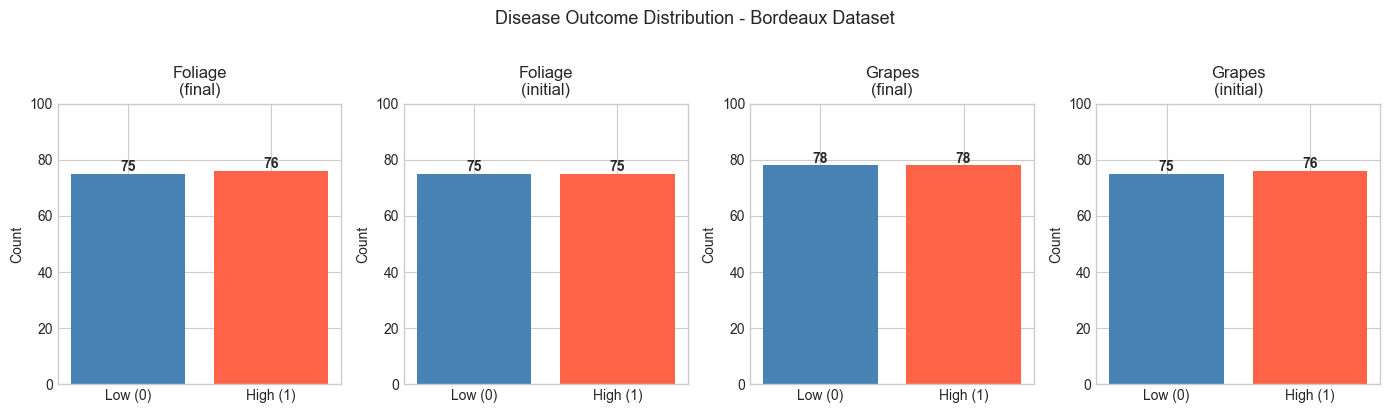

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

targets = ['MFF_fin', 'MFI_fin', 'MGF_fin', 'MGI_fin']
labels = ['Foliage\n(final)', 'Foliage\n(initial)', 'Grapes\n(final)', 'Grapes\n(initial)']

for ax, col, label in zip(axes, targets, labels):
    counts = bordeaux[col].value_counts().sort_index()
    ax.bar(['Low (0)', 'High (1)'], counts.values, color=['steelblue', 'tomato'])
    ax.set_title(label)
    ax.set_ylabel('Count')
    ax.set_ylim(0, 100)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.suptitle('Disease Outcome Distribution - Bordeaux Dataset', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

All four outcome variables are nearly perfectly balanced: each shows approximately 75-78 records per class. This confirms the stratifiednature of the dataset noted in the original study - the 50/50 split was by design, not a natural occurence rate

### 2.2 Weather Variable Distributions

Distribution of monthly precipitation and mean temperatre accross all site-years (March-June). These are the predictor variables used in the subsequent analysis.

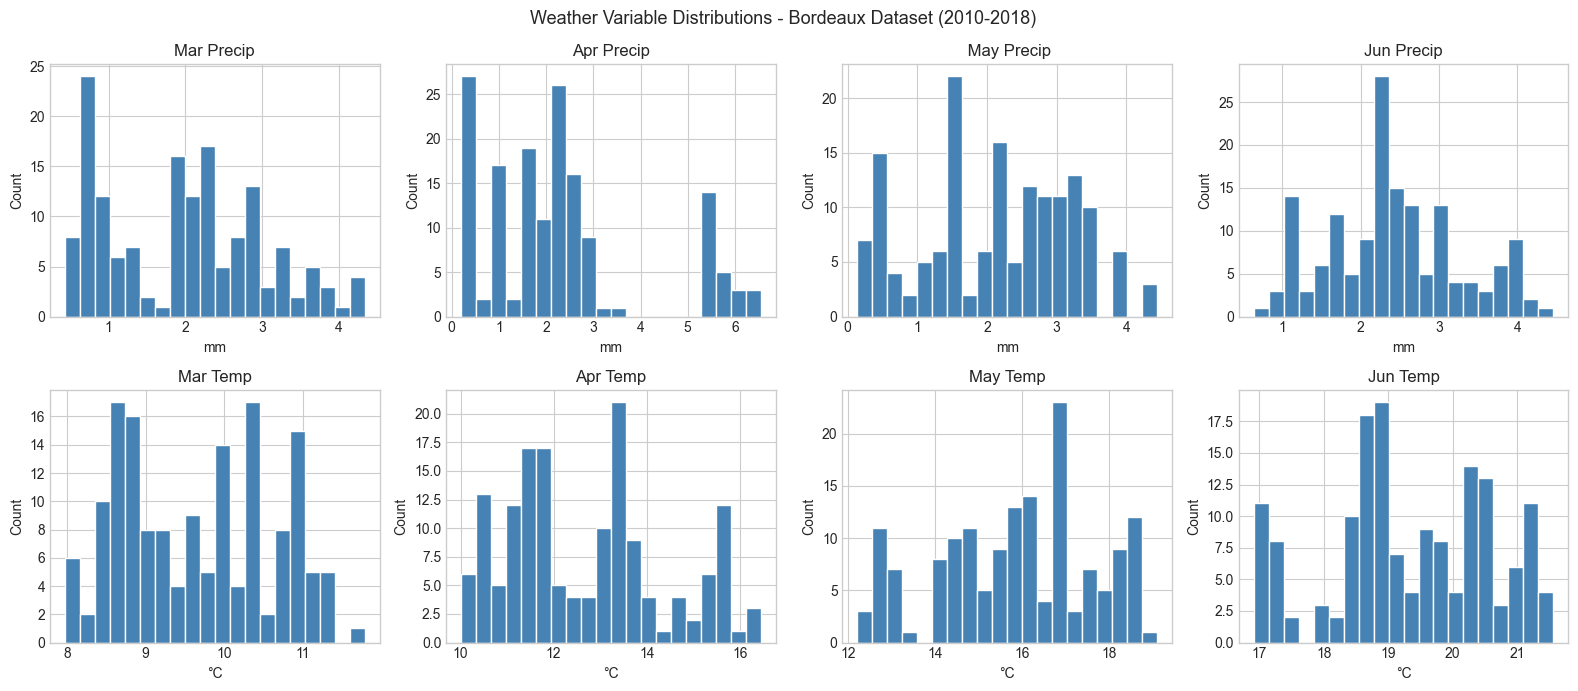

In [21]:
weather_cols = [
    'Mar_p_total_moy', 'Apr_p_total_moy', 'May_p_total_moy', 'Jun_p_total_moy',
    'Mar_tmean_h_q_moy', 'Apr_tmean_h_q_moy', 'May_tmean_h_q_moy', 'Jun_tmean_h_q_moy'
]

col_labels = [
    'Mar Precip', 'Apr Precip', ' May Precip', 'Jun Precip',
    'Mar Temp', 'Apr Temp', 'May Temp', 'Jun Temp'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, col, label in zip(axes.flatten(), weather_cols, col_labels):
    ax.hist(bordeaux[col], bins=20, color='steelblue', edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('mm' if 'Precip' in label else '°C')
    ax.set_ylabel('Count')

plt.suptitle("Weather Variable Distributions - Bordeaux Dataset (2010-2018)", fontsize=13)
plt.tight_layout()
plt.show()

Precipitation distributions are right-skewed across all months, with most site-years recording low monthly totals and fewer recording high rainfall events. Temperature distributions are approximately bell-shaped and show a clear seasonal progression:
March (8–12 °C) → April (10–16 °C) → May (12–19 °C) → June (17–22 °C),
consistent with the Bordeaux climate. No extreme outliers are visible in either variable group.

### 2.3 Correlation Heatmap

Pairwise Pearson correlations between all weather variables and disease outcomes.
This gives an initial indication of which meteorological factors co-vary with high disease incidence.

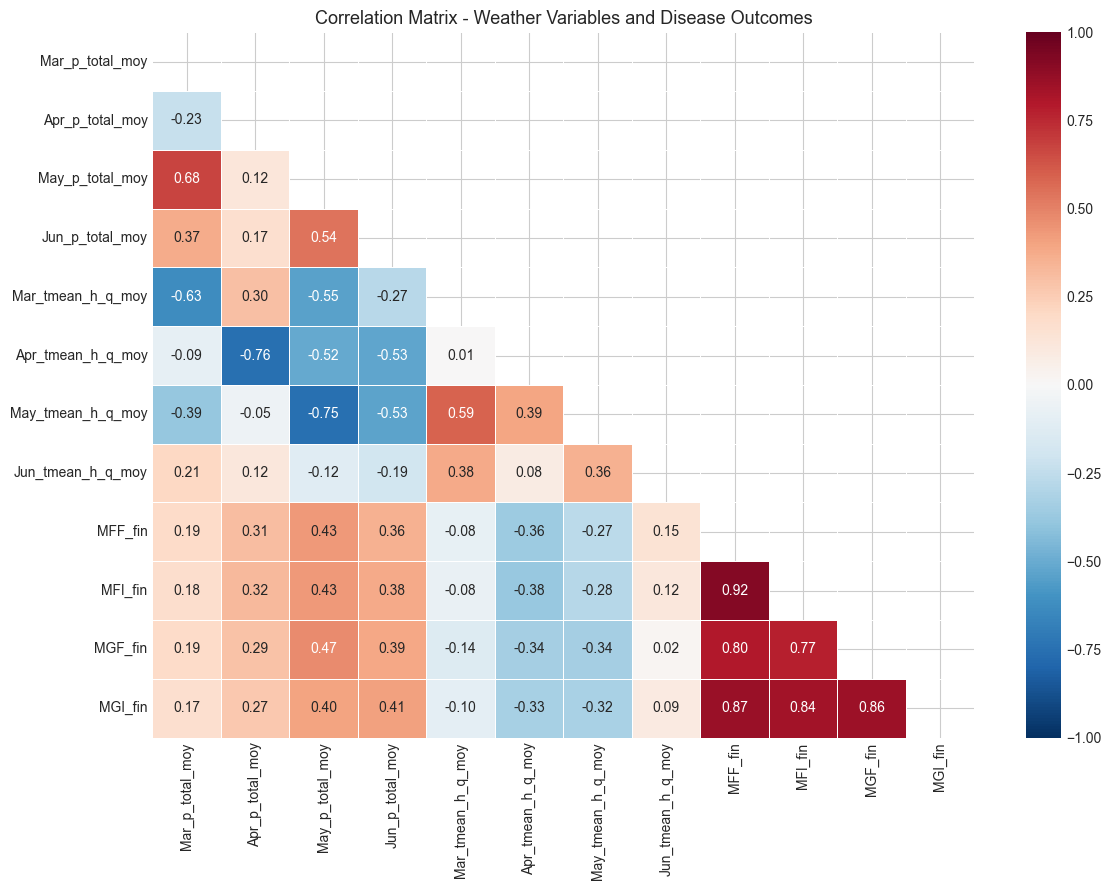

In [24]:
fig, ax = plt.subplots(figsize=(12, 9))

corr = bordeaux[weather_cols + targets].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5
)

ax.set_title("Correlation Matrix - Weather Variables and Disease Outcomes", fontsize=13)
plt.tight_layout()
plt.show()

The strongest correlations with disease outcomes are observerd for May precipitation (r ≈ 0.43–0.47) and April-May temperatures (r ≈ −0.33 to −0.38).
Higher spring rainfall and lower spring temperatures are associated with increased disease incidence. The four outcome variables are strongly inter-correlated (r = 0.77-0.92), suggesting they capture the same underlying disease event from different angles.

### 2.4 Disease Incidence by Year

Proportion of high-incidence records (outcome = 1) per year across all four outcome variables. This reveals whether certain years were systematically worse for disease development.

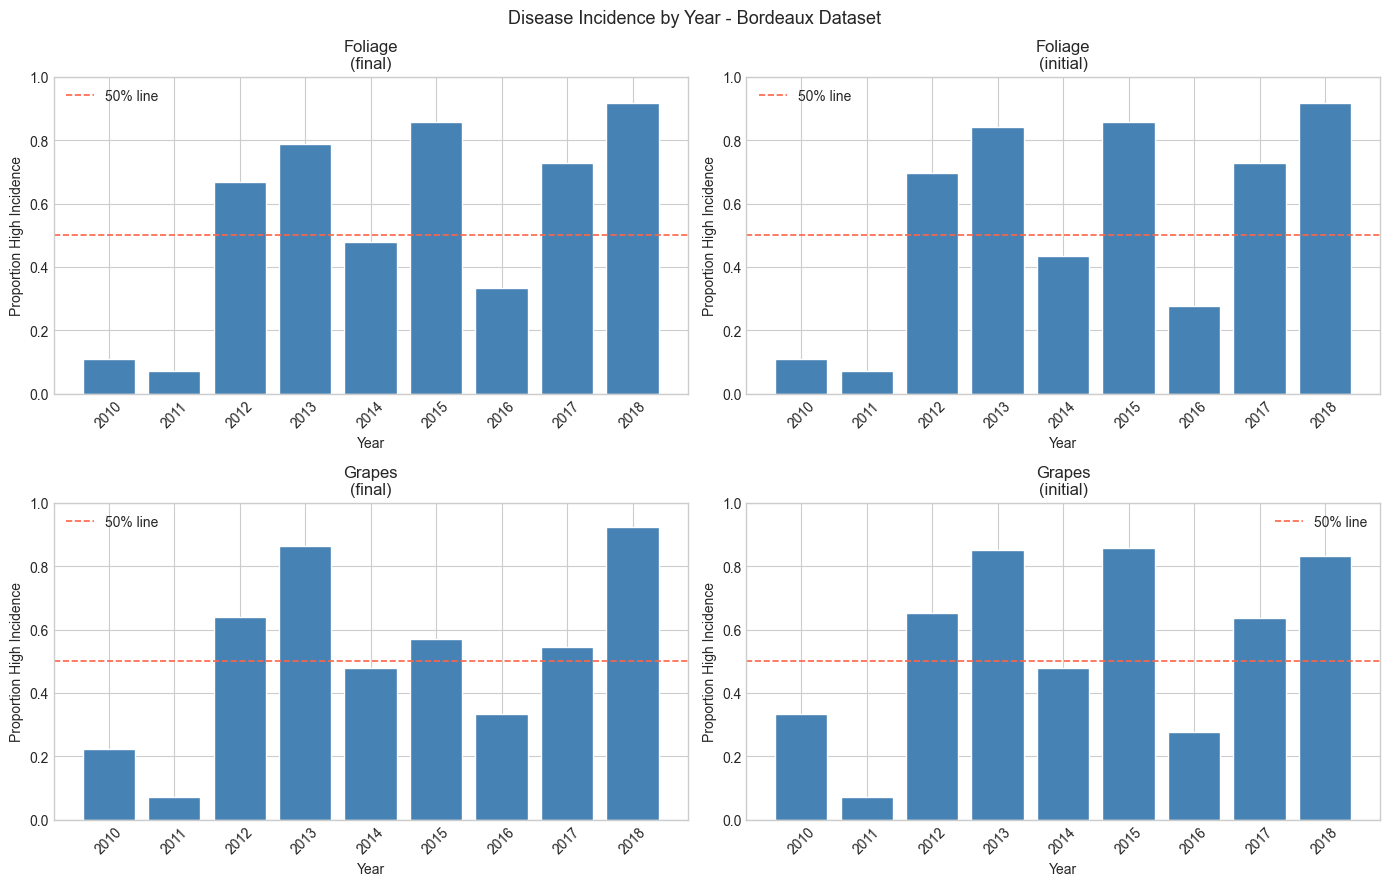

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

year_map = {1: 2010, 2: 2011, 3: 2012, 4: 2013, 5: 2014,
           6: 2015, 7: 2016, 8: 2017, 9: 2018}
bordeaux["Year_actual"] = bordeaux["Year"].map(year_map)

for ax, col, label in zip(axes.flatten(), targets, labels):
    yearly = bordeaux.groupby("Year_actual")[col].mean()
    ax.bar(yearly.index, yearly.values, color="steelblue", edgecolor="white")
    ax.axhline(0.5, color="tomato", linestyle="--", linewidth=1.2, label="50% line")
    ax.set_title(label)
    ax.set_xlabel("Year")
    ax.set_ylabel("Proportion High Incidence")
    ax.set_ylim(0, 1)
    ax.set_xticks(yearly.index)
    ax.set_xticklabels(yearly.index, rotation=45)
    ax.legend()

plt.suptitle("Disease Incidence by Year - Bordeaux Dataset", fontsize=13)
plt.tight_layout()
plt.show()

Desease incidence varies considerably across years and is consistent across all four outco,e variables - years with high foliage incidence year across all outcomes, while 2018 shows the highest. 2016 also recorded 